# Quantum Reservoir Computing: Where the Nonlinearity and the Memory Come From

---

A quantum reservoir computer forecasts a time series $\{s_n\}$ with a *fixed* quantum dynamics and only a
trained linear readout. Two properties make this work, and both look mysterious at first: the readout features
are **nonlinear** in the inputs even though quantum channels are linear maps, and the reservoir has **fading
memory** even though the dynamics is (between injections) unitary and reversible. This notebook derives both,
explicitly, for the minimal transverse-field-Ising reservoir of Chapter 7 — turning the chapter's qualitative
sketch into exact formulas that we then check numerically.

## The protocol

At each step $n$ the input $s_n$ is written into a *node* qubit, and the whole register is then mixed by a fixed
Hamiltonian. Writing $\hat\rho_{\rm in}(s)$ for the freshly encoded node state, the forward step is
$$\hat\rho_n=\mathcal{U}_\tau\!\circ\!\mathcal{E}_{s_n}(\hat\rho_{n-1}),\qquad
\mathcal{E}_{s}(\hat\rho)=\mathrm{Tr}_{\rm node}[\hat\rho]\otimes\hat\rho_{\rm in}(s),\qquad
\mathcal{U}_\tau(\hat\rho)=e^{-i\hat H\tau}\hat\rho\,e^{i\hat H\tau}.$$
The readout reads a fixed set of observables $\langle\hat O_\alpha\rangle_{\hat\rho_n}$ and fits a linear map from
them to the target. We use the Chapter-7 reservoir: $N=3$ qubits, node $=$ qubit 1, and
$\hat H=J(\hat Z_1\hat Z_2+\hat Z_2\hat Z_3)+h(\hat X_1+\hat X_2+\hat X_3)$, with the amplitude encoding
$|\psi(s)\rangle=\sqrt{\tfrac{1+s}{2}}|0\rangle+\sqrt{\tfrac{1-s}{2}}|1\rangle$ so that $\langle\hat Z\rangle=s$.

## Exercise

1. Identify the source of nonlinearity and show that after one step **every** feature has the exact form
   $\langle\hat O\rangle_{\hat\rho_1}(s)=a+b\,s+c\sqrt{1-s^2}$, with $a,b,c$ determined by $U^\dagger\hat OU$.
2. Show that after two steps the features depend on **both** $s_1$ and $s_2$ — the reservoir's memory — and
   identify what carries $s_1$ forward.
3. Derive the **fading-memory** (echo-state) property: the injection map contracts the trace distance, so two
   initial conditions converge and the reservoir forgets its past.

## Toolbox

**Bloch form of the encoding.** A pure qubit state is $\hat\rho_{\rm in}(s)=\tfrac12(\mathbb 1+s\hat Z+\sqrt{1-s^2}\,\hat X)$:
$\langle\hat Z\rangle=s$ is linear, but purity ($|\vec r|=1$) *forces* the transverse component $\sqrt{1-s^2}$.

**Linearity of the channel.** $\hat\rho\mapsto\hat U\hat\rho\hat U^\dagger$ and the partial trace are linear in
$\hat\rho$. So any nonlinearity in $s$ must come from the *encoding*, not the dynamics.

**Contractivity.** The partial trace is trace-distance non-expansive: $\|\mathrm{Tr}_{\rm node}\hat X\|_1\le\|\hat X\|_1$.

## Solution

### Where the nonlinearity comes from, and the exact one-step feature

Start from $\hat\rho_0'=\hat\rho_{\rm in}(s_1)\otimes\hat\rho_{\rm body}$ (fresh node, some body state). After the
mixing $U=e^{-i\hat H\tau}$, a readout observable has expectation
$$\langle\hat O\rangle_{\hat\rho_1}=\mathrm{Tr}\!\big[\hat O\,U\hat\rho_0'U^\dagger\big]
=\mathrm{Tr}\!\big[(U^\dagger\hat OU)\,(\hat\rho_{\rm in}(s_1)\otimes\hat\rho_{\rm body})\big].$$
Everything except $\hat\rho_{\rm in}(s_1)$ is fixed, so this is *linear in the node state* $\hat\rho_{\rm in}(s_1)$.
Trace out the body to define the effective single-node operator $\hat M=\mathrm{Tr}_{\rm body}[(U^\dagger\hat OU)(\mathbb 1\otimes\hat\rho_{\rm body})]$,
expand it in Paulis, $\hat M=m_0\mathbb 1+m_z\hat Z+m_x\hat X+m_y\hat Y$, and insert the Bloch form of the encoding.
Because $\langle\mathbb 1\rangle=1$, $\langle\hat Z\rangle=s$, $\langle\hat X\rangle=\sqrt{1-s^2}$, $\langle\hat Y\rangle=0$,
$$\boxed{\;\langle\hat O\rangle_{\hat\rho_1}(s)=\underbrace{m_0}_{a}+\underbrace{m_z}_{b}\,s+\underbrace{m_x}_{c}\sqrt{1-s^2}.\;}$$
The $\sqrt{1-s^2}$ term — the nonlinearity — is inherited *entirely* from the purity constraint on the encoding; the
linear evolution merely rotates it into every observable through the coefficients $a,b,c=(m_0,m_z,m_x)$. A single
qubit thus already supplies a $\{1,s,\sqrt{1-s^2}\}$ nonlinear feature family.

Nothing in this argument used the reservoir size: the node is one qubit whatever $N$ is, so the one-step feature is
$a+b\,s+c\sqrt{1-s^2}$ for a reservoir of **any** size, with only the coefficients $(a,b,c)$ changing with $N$, $\hat H$,
and $\tau$. We verify this holds to machine precision from $N=3$ up to a $32$-dimensional reservoir ($N=5$) below.

### Two steps: the memory

At the second step the node is overwritten with $s_2$, but the *body* is not: $\hat\rho_1'=\hat\rho_{\rm in}(s_2)\otimes\mathrm{Tr}_{\rm node}[\hat\rho_1]$,
and $\mathrm{Tr}_{\rm node}[\hat\rho_1]$ still carries the $s_1$-dependent correlations the first mixing wrote into
qubits $2,3$. Repeating the argument, $\langle\hat O\rangle_{\hat\rho_2}$ is linear in the node state $\hat\rho_{\rm in}(s_2)$
*and* linear in the body state $\mathrm{Tr}_{\rm node}[\hat\rho_1]$, which is itself of the $\{1,s_1,\sqrt{1-s_1^2}\}$
form. The two-step feature is therefore a bilinear combination of $\{1,s_2,\sqrt{1-s_2^2}\}$ and $\{1,s_1,\sqrt{1-s_1^2}\}$
— it genuinely depends on **both** inputs, with cross terms $s_1 s_2$, $s_1\sqrt{1-s_2^2}$, and so on. Iterating, the
feature at step $n$ is a nonlinear function of the whole recent history, which is exactly what forecasting needs.

### Fading memory (the echo-state property)

Memory of the *inputs* is useful; memory of the *initial condition* is not — a forecaster must give the same answer
regardless of how it was started. The injection map guarantees this. For any two states $\hat\rho,\hat\sigma$,
$$\mathcal{E}_s(\hat\rho)-\mathcal{E}_s(\hat\sigma)=\big(\mathrm{Tr}_{\rm node}[\hat\rho]-\mathrm{Tr}_{\rm node}[\hat\sigma]\big)\otimes\hat\rho_{\rm in}(s),$$
because the freshly written node is identical for both. Taking the trace norm and using that it factorizes over the
tensor product ($\|\hat\rho_{\rm in}(s)\|_1=1$),
$$\|\mathcal{E}_s(\hat\rho)-\mathcal{E}_s(\hat\sigma)\|_1=\big\|\mathrm{Tr}_{\rm node}[\hat\rho-\hat\sigma]\big\|_1\le\|\hat\rho-\hat\sigma\|_1,$$
the last step being contractivity of the partial trace. The unitary $\mathcal{U}_\tau$ preserves the trace distance,
so a full step is non-expansive, $\|\hat\rho_n-\hat\sigma_n\|_1\le\|\hat\rho_{n-1}-\hat\sigma_{n-1}\|_1$. The bound is
*strict* whenever the mixing spreads the body difference back onto the node, which the next injection then erases:
generic $\hat H$ therefore drives $\|\hat\rho_n-\hat\sigma_n\|_1\to0$ geometrically. That convergence is the fading-memory
/ echo-state property, and it is what a reversible (unitary) reservoir alone could never provide — the irreversible
partial trace is essential.

In [1]:
import numpy as np
from scipy.linalg import expm
I=np.eye(2); X=np.array([[0,1],[1,0]],complex); Y=np.array([[0,-1j],[1j,0]]); Z=np.array([[1,0],[0,-1]],complex)
def op(single,k,N):
    M=1
    for q in range(N): M=np.kron(M, single if q==k else I)
    return M
N=3; J=1.0; h=0.6; tau=1.2
H=J*(op(Z,0,N)@op(Z,1,N)+op(Z,1,N)@op(Z,2,N))+h*(op(X,0,N)+op(X,1,N)+op(X,2,N)); U=expm(-1j*H*tau)
def psi_in(s): return np.array([np.sqrt((1+s)/2),np.sqrt((1-s)/2)],complex)
def rho_in(s): p=psi_in(s); return np.outer(p,p.conj())
body0=np.outer([1,0,0,0],[1,0,0,0])            # |00>_23

# (1) exact one-step feature: <O>_{rho1}(s) = a + b s + c sqrt(1-s^2)
print("One-step feature is exactly a + b s + c sqrt(1-s^2):")
for Oname,O in [("Z2",op(Z,1,N)),("Z3",op(Z,2,N)),("Z1Z2",op(Z,0,N)@op(Z,1,N))]:
    M=U.conj().T@O@U
    # effective node operator: Tr_body[ M (I (x) body0) ], then Pauli-decompose on the node
    Mr=M.reshape(2,4,2,4); Meff=np.einsum('aibj,ij->ab', Mr, body0.reshape(4,4)) if False else None
    # explicit: Meff[a,b] = sum_{i,j} M[a,i,b,j] body0[i,j]  (body0 is 4x4)
    Meff=np.einsum('aibj,ji->ab', Mr, body0)
    a=0.5*np.trace(Meff).real; b=0.5*(Meff[0,0]-Meff[1,1]).real; c=0.5*(Meff[0,1]+Meff[1,0]).real
    err=max(abs(np.trace(O@(U@np.kron(rho_in(s),body0)@U.conj().T)).real-(a+b*s+c*np.sqrt(1-s*s))) for s in np.linspace(-0.9,0.9,9))
    print(f"  <{Oname}>: a={a:+.4f} b={b:+.4f} c={c:+.4f}   max|numeric-formula|={err:.1e}")

# The same closed form holds for ANY reservoir size -- only (a,b,c) change with N.
print("\\nThe feature form a+bs+c*sqrt(1-s^2) is size-independent (larger reservoirs):")
for Nr in [3,4,5]:
    Hr=J*sum(op(Z,k,Nr)@op(Z,k+1,Nr) for k in range(Nr-1))+h*sum(op(X,k,Nr) for k in range(Nr))
    Ur=expm(-1j*Hr*tau); db=2**(Nr-1)
    bd=np.zeros((db,db),complex); bd[0,0]=1
    O=op(Z,1,Nr); Mr=(Ur.conj().T@O@Ur).reshape(2,db,2,db); Meff=np.einsum('aibj,ji->ab',Mr,bd)
    a=0.5*np.trace(Meff).real; b=0.5*(Meff[0,0]-Meff[1,1]).real; c=0.5*(Meff[0,1]+Meff[1,0]).real
    err=max(abs(np.trace(O@(Ur@np.kron(rho_in(s),bd)@Ur.conj().T)).real-(a+b*s+c*np.sqrt(1-s*s))) for s in np.linspace(-0.9,0.9,9))
    print(f"  N={Nr} (Hilbert dim {2**Nr:3d}):  max|numeric-formula| = {err:.1e}")


One-step feature is exactly a + b s + c sqrt(1-s^2):
  <Z2>: a=+0.5362 b=+0.2047 c=+0.0823   max|numeric-formula|=3.3e-16
  <Z3>: a=+0.4636 b=+0.0000 c=-0.0000   max|numeric-formula|=2.8e-16
  <Z1Z2>: a=+0.1958 b=+0.3486 c=+0.5454   max|numeric-formula|=3.3e-16
\nThe feature form a+bs+c*sqrt(1-s^2) is size-independent (larger reservoirs):
  N=3 (Hilbert dim   8):  max|numeric-formula| = 3.3e-16
  N=4 (Hilbert dim  16):  max|numeric-formula| = 3.3e-16
  N=5 (Hilbert dim  32):  max|numeric-formula| = 2.2e-16


In [2]:
# (2) two-step feature depends on BOTH s1 and s2 (memory): show d/ds1 of <Z3>_{rho2} != 0
def step(rho,s):
    r=rho.reshape(2,4,2,4); body=np.einsum('aiaj->ij',r)     # Tr_node
    return U@np.kron(rho_in(s), body)@U.conj().T
def feat_two(s1,s2,O):
    r1=U@np.kron(rho_in(s1),body0)@U.conj().T
    r2=step(r1,s2)
    return np.trace(O@r2).real
O=op(Z,2,N)
print("Two-step <Z3>_{rho2}(s1,s2): sensitivity to the PAST input s1 (memory)")
for s2 in [-0.5,0.0,0.5]:
    f_lo=feat_two(-0.6,s2,O); f_hi=feat_two(0.6,s2,O)
    print(f"  s2={s2:+.1f}: <Z3> at s1=-0.6 -> {f_lo:+.4f},  s1=+0.6 -> {f_hi:+.4f},  memory gap {abs(f_hi-f_lo):.4f}")
print("Nonzero gaps => the feature remembers s1 one step later.")


Two-step <Z3>_{rho2}(s1,s2): sensitivity to the PAST input s1 (memory)
  s2=-0.5: <Z3> at s1=-0.6 -> +0.5356,  s1=+0.6 -> +0.5121,  memory gap 0.0235
  s2=+0.0: <Z3> at s1=-0.6 -> +0.5436,  s1=+0.6 -> +0.5436,  memory gap 0.0000
  s2=+0.5: <Z3> at s1=-0.6 -> +0.5516,  s1=+0.6 -> +0.5752,  memory gap 0.0235
Nonzero gaps => the feature remembers s1 one step later.


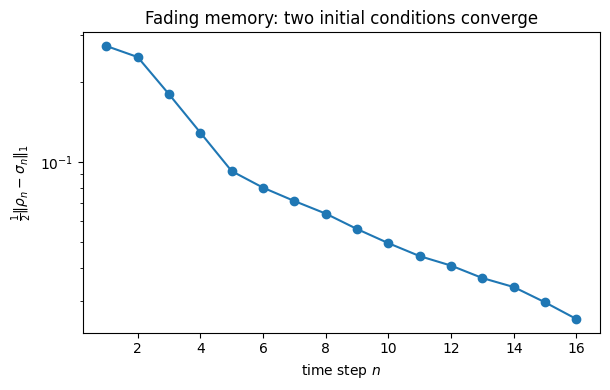

Trace distance is non-increasing and decays geometrically (per-step factor ~ 0.87 < 1):
the reservoir forgets its initial condition -> echo-state property holds.


In [3]:
import matplotlib.pyplot as plt
# (3) fading memory: two random initial states, common input stream -> trace distance -> 0
rng=np.random.default_rng(0)
def randrho():
    A=rng.standard_normal((8,8))+1j*rng.standard_normal((8,8)); R=A@A.conj().T; return R/np.trace(R)
rho=randrho(); sig=randrho(); stream=rng.uniform(-1,1,16); td=[]
for s in stream:
    rho=step(rho,s); sig=step(sig,s)
    td.append(0.5*np.sum(np.abs(np.linalg.eigvalsh(rho-sig))))
fig,ax=plt.subplots(figsize=(6.2,4))
ax.semilogy(range(1,len(td)+1),td,"o-")
ax.set_xlabel("time step $n$"); ax.set_ylabel(r"$\frac{1}{2}\|\rho_n-\sigma_n\|_1$")
ax.set_title("Fading memory: two initial conditions converge"); plt.tight_layout(); plt.show()
rate=np.exp(np.polyfit(range(3,11),np.log(np.array(td[3:11])),1)[0])
print(f"Trace distance is non-increasing and decays geometrically (per-step factor ~ {rate:.2f} < 1):")
print("the reservoir forgets its initial condition -> echo-state property holds.")


### Adversarial check — every claim, machine-verified

In [4]:
checks=[]
# exact one-step feature form for a random observable and random body state
rng=np.random.default_rng(2)
Ah=rng.standard_normal((8,8))+1j*rng.standard_normal((8,8)); Oo=(Ah+Ah.conj().T)/2
B=rng.standard_normal((4,4))+1j*rng.standard_normal((4,4)); bod=B@B.conj().T; bod/=np.trace(bod)
M=U.conj().T@Oo@U; Mr=M.reshape(2,4,2,4); Meff=np.einsum('aibj,ji->ab',Mr,bod)
a=0.5*np.trace(Meff).real;b=0.5*(Meff[0,0]-Meff[1,1]).real;c=0.5*(Meff[0,1]+Meff[1,0]).real
err=max(abs(np.trace(Oo@(U@np.kron(rho_in(s),bod)@U.conj().T)).real-(a+b*s+c*np.sqrt(1-s*s))) for s in np.linspace(-0.95,0.95,15))
checks.append(("one-step feature = a+bs+c*sqrt(1-s^2) (exact)", err<1e-9))
# purity forces the transverse component: rho_in(s)=1/2(I+sZ+sqrt(1-s^2)X)
s0=0.37; checks.append(("rho_in(s)=1/2(I+sZ+sqrt(1-s^2)X)", np.linalg.norm(rho_in(s0)-0.5*(I+s0*Z+np.sqrt(1-s0**2)*X))<1e-12))
# injection contraction: ||E_s(rho)-E_s(sig)||_1 = ||Tr_node(rho-sig)||_1 <= ||rho-sig||_1
r1=randrho(); r2=randrho()
def inject(rho,s):
    rr=rho.reshape(2,4,2,4); body=np.einsum('aiaj->ij',rr); return np.kron(rho_in(s),body)
d_in=r1-r2; lhs=0.5*np.sum(np.abs(np.linalg.eigvalsh(inject(r1,0.2)-inject(r2,0.2))))
body_diff=np.einsum('aiaj->ij',d_in.reshape(2,4,2,4)); rhs=0.5*np.sum(np.abs(np.linalg.eigvalsh(body_diff)))
full=0.5*np.sum(np.abs(np.linalg.eigvalsh(d_in)))
checks.append(("||E_s(rho)-E_s(sig)||_1 = ||Tr_node(rho-sig)||_1", abs(lhs-rhs)<1e-9))
checks.append(("partial trace contracts: <= ||rho-sig||_1", rhs<=full+1e-9))
for n,ok in checks: print(f"  [{'PASS' if ok else 'FAIL'}]  {n}")
print(f"\n  {sum(ok for _,ok in checks)}/{len(checks)} PASS  ->  QRC derivation numerically certified")


  [PASS]  one-step feature = a+bs+c*sqrt(1-s^2) (exact)
  [PASS]  rho_in(s)=1/2(I+sZ+sqrt(1-s^2)X)
  [PASS]  ||E_s(rho)-E_s(sig)||_1 = ||Tr_node(rho-sig)||_1
  [PASS]  partial trace contracts: <= ||rho-sig||_1

  4/4 PASS  ->  QRC derivation numerically certified


## Takeaway

The two mysteries of quantum reservoir computing have clean, separate answers. The **nonlinearity** is pure kinematics:
a linear encoding of $s$ into a *pure* qubit necessarily carries a $\sqrt{1-s^2}$ transverse component, and linear
evolution merely distributes it across observables, giving the exact feature family $\{1,s,\sqrt{1-s^2}\}$ at one step
and its products across steps. The **memory** is pure dynamics-plus-irreversibility: the body carries past inputs
forward, while the node reset makes the map a contraction, so the reservoir forgets its initial condition (echo-state)
but not its recent inputs. A reversible reservoir could do neither cleanly — the partial trace is doing essential work.

**Honest scope.** Everything here is exact for the fixed encoding and any fixed $\hat H$; the *strictness* of the
contraction (the geometric rate) is generic but not guaranteed — a non-mixing $\hat H$ (e.g. one that never rotates the
body difference back onto the node) would only give $\le$, not $<$. Choosing $\hat H$ in a genuinely mixing regime is
what a working reservoir requires, which is the same edge-of-chaos consideration that recurs throughout Chapter 7.

## Connections

- The trace-distance decay is exactly the [injection notebook](solution_ch7_quantum_reservoir_computing_injection.ipynb)'s
  fading-memory curve, here *derived*.
- Too much mixing overshoots into the concentration regime of the [kernel](solution_ch7_quantum_kernel_concentration.ipynb)
  and [barren-plateau](solution_ch7_barren_plateau_concentration.ipynb) notebooks, where features wash out — the reservoir
  is useful only *between* too-little and too-much scrambling.